In [4]:
!nvidia-smi

Thu Jul  9 10:26:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Cell 1 — Check Colab GPU

In [5]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

assert torch.cuda.is_available(), (
    "GPU is not enabled. Select Runtime → Change runtime type → T4 GPU."
)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


Cell 2 — Clone the official repository



In [6]:
%cd /content

!rm -rf CMUNeXt
!git clone https://github.com/FengheTan9/CMUNeXt.git

%cd /content/CMUNeXt

!git rev-parse HEAD
!ls

/content
Cloning into 'CMUNeXt'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 70 (delta 20), reused 19 (delta 19), pack-reused 42 (from 1)
Receiving objects: 100% (70/70), 457.13 KiB | 12.35 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/CMUNeXt
affbf03ef631bb318d87b73ef97b2eacd0a5de85
dataloader  LICENSE  network	requirements.txt  utils
imgs	    main.py  README.md	split.py


Cell 3 — Check dependencies safely

In [7]:
import importlib.util
import subprocess
import sys

required_packages = {
    "albumentations": "albumentations>=1.4.24,<3",
    "cv2": "opencv-python-headless",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
    "requests": "requests",
    "matplotlib": "matplotlib",
}

missing_packages = [
    package
    for module, package in required_packages.items()
    if importlib.util.find_spec(module) is None
]

if missing_packages:
    print("Installing missing packages:", missing_packages)

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        *missing_packages
    ])
else:
    print("All required packages are already installed.")

All required packages are already installed.


In [8]:
import torch
import numpy as np
import cv2
import albumentations as A
import sklearn

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("Albumentations:", A.__version__)
print("Scikit-learn:", sklearn.__version__)

PyTorch: 2.11.0+cu128
CUDA: True
NumPy: 2.0.2
OpenCV: 4.13.0
Albumentations: 2.0.8
Scikit-learn: 1.6.1


Cell 4 — Create the Colab-compatible base training script

In [9]:
%%writefile /content/CMUNeXt/train_colab.py

import argparse
import csv
import os
import random
from pathlib import Path

import albumentations as A
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

from dataloader.dataset import MedicalDataSets
from network.CMUNeXt import cmunext, cmunext_l, cmunext_s
from utils.losses import BCEDiceLoss
from utils.metrics import iou_score
from utils.util import AverageMeter


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def build_model(model_name: str) -> torch.nn.Module:
    if model_name == "CMUNeXt":
        model = cmunext()
    elif model_name == "CMUNeXt-S":
        model = cmunext_s()
    elif model_name == "CMUNeXt-L":
        model = cmunext_l()
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    return model.cuda()


def build_dataloaders(args):
    train_transform = A.Compose([
        A.RandomRotate90(p=0.5),

        A.OneOf([
            A.HorizontalFlip(p=1.0),
            A.VerticalFlip(p=1.0),
        ], p=0.5),

        A.Resize(args.image_size, args.image_size),
        A.Normalize(),
    ])

    validation_transform = A.Compose([
        A.Resize(args.image_size, args.image_size),
        A.Normalize(),
    ])

    train_dataset = MedicalDataSets(
        base_dir=args.base_dir,
        split="train",
        transform=train_transform,
        train_file_dir=args.train_file_dir,
        val_file_dir=args.val_file_dir,
    )

    validation_dataset = MedicalDataSets(
        base_dir=args.base_dir,
        split="val",
        transform=validation_transform,
        train_file_dir=args.train_file_dir,
        val_file_dir=args.val_file_dir,
    )

    print(
        f"Training samples: {len(train_dataset)}, "
        f"validation samples: {len(validation_dataset)}"
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=args.num_workers,
        pin_memory=True,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=True,
    )

    return train_loader, validation_loader


def save_history(history, output_path: str) -> None:
    path = Path(output_path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if not history:
        return

    with path.open("w", newline="") as file:
        writer = csv.DictWriter(
            file,
            fieldnames=list(history[0].keys())
        )
        writer.writeheader()
        writer.writerows(history)


def train(args):
    seed_everything(args.seed)

    train_loader, validation_loader = build_dataloaders(args)
    model = build_model(args.model)

    optimizer = optim.SGD(
        model.parameters(),
        lr=args.base_lr,
        momentum=0.9,
        weight_decay=1e-4,
    )

    criterion = BCEDiceLoss().cuda()

    iterations_per_epoch = len(train_loader)
    maximum_iterations = iterations_per_epoch * args.max_epochs

    print("Model:", args.model)
    print("Image size:", args.image_size)
    print("Batch size:", args.batch_size)
    print("Epochs:", args.max_epochs)
    print("Initial learning rate:", args.base_lr)
    print("Iterations per epoch:", iterations_per_epoch)

    best_iou = -1.0
    iteration = 0
    history = []

    checkpoint_directory = Path(args.checkpoint_dir)
    checkpoint_directory.mkdir(parents=True, exist_ok=True)

    checkpoint_name = (
        f"{args.model}_{Path(args.train_file_dir).stem}_best.pth"
    )
    checkpoint_path = checkpoint_directory / checkpoint_name

    for epoch in range(args.max_epochs):
        model.train()

        train_loss_meter = AverageMeter()
        train_iou_meter = AverageMeter()

        for sampled_batch in train_loader:
            images = sampled_batch["image"].cuda(
                non_blocking=True
            )
            labels = sampled_batch["label"].cuda(
                non_blocking=True
            )

            predictions = model(images)
            loss = criterion(predictions, labels)

            train_iou, _, _, _, _, _, _ = iou_score(
                predictions,
                labels
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Original polynomial learning-rate strategy
            learning_rate = args.base_lr * (
                1.0 - iteration / maximum_iterations
            ) ** 0.9

            for parameter_group in optimizer.param_groups:
                parameter_group["lr"] = learning_rate

            iteration += 1

            train_loss_meter.update(
                loss.item(),
                images.size(0)
            )
            train_iou_meter.update(
                train_iou,
                images.size(0)
            )

        model.eval()

        validation_loss_meter = AverageMeter()
        validation_iou_meter = AverageMeter()
        sensitivity_meter = AverageMeter()
        precision_meter = AverageMeter()
        f1_meter = AverageMeter()
        accuracy_meter = AverageMeter()

        with torch.no_grad():
            for sampled_batch in validation_loader:
                images = sampled_batch["image"].cuda(
                    non_blocking=True
                )
                labels = sampled_batch["label"].cuda(
                    non_blocking=True
                )

                predictions = model(images)
                loss = criterion(predictions, labels)

                (
                    validation_iou,
                    _,
                    sensitivity,
                    precision,
                    f1,
                    _,
                    accuracy,
                ) = iou_score(predictions, labels)

                validation_loss_meter.update(
                    loss.item(),
                    images.size(0)
                )
                validation_iou_meter.update(
                    validation_iou,
                    images.size(0)
                )
                sensitivity_meter.update(
                    sensitivity,
                    images.size(0)
                )
                precision_meter.update(
                    precision,
                    images.size(0)
                )
                f1_meter.update(
                    f1,
                    images.size(0)
                )
                accuracy_meter.update(
                    accuracy,
                    images.size(0)
                )

        epoch_result = {
            "epoch": epoch + 1,
            "learning_rate": learning_rate,
            "train_loss": train_loss_meter.avg,
            "train_iou": train_iou_meter.avg,
            "validation_loss": validation_loss_meter.avg,
            "validation_iou": validation_iou_meter.avg,
            "validation_sensitivity": sensitivity_meter.avg,
            "validation_precision": precision_meter.avg,
            "validation_f1": f1_meter.avg,
            "validation_accuracy": accuracy_meter.avg,
        }

        history.append(epoch_result)
        save_history(history, args.history_csv)

        print(
            f"Epoch [{epoch + 1}/{args.max_epochs}] "
            f"train_loss={train_loss_meter.avg:.4f}, "
            f"train_iou={train_iou_meter.avg:.4f}, "
            f"val_loss={validation_loss_meter.avg:.4f}, "
            f"val_iou={validation_iou_meter.avg:.4f}, "
            f"val_SE={sensitivity_meter.avg:.4f}, "
            f"val_PC={precision_meter.avg:.4f}, "
            f"val_F1={f1_meter.avg:.4f}, "
            f"val_ACC={accuracy_meter.avg:.4f}"
        )

        if validation_iou_meter.avg > best_iou:
            best_iou = validation_iou_meter.avg

            torch.save(
                model.state_dict(),
                checkpoint_path
            )

            print(
                f"=> Saved best checkpoint: {checkpoint_path}"
            )
            print(f"=> Best validation IoU: {best_iou:.4f}")

    print("Training finished.")
    print("Best validation IoU:", best_iou)
    print("Best checkpoint:", checkpoint_path)


def parse_arguments():
    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--model",
        type=str,
        default="CMUNeXt",
        choices=["CMUNeXt", "CMUNeXt-S", "CMUNeXt-L"],
    )

    parser.add_argument(
        "--base_dir",
        type=str,
        default="./data/busi",
    )

    parser.add_argument(
        "--train_file_dir",
        type=str,
        default="busi_train.txt",
    )

    parser.add_argument(
        "--val_file_dir",
        type=str,
        default="busi_val.txt",
    )

    parser.add_argument(
        "--base_lr",
        type=float,
        default=0.01,
    )

    parser.add_argument(
        "--batch_size",
        type=int,
        default=8,
    )

    parser.add_argument(
        "--max_epochs",
        type=int,
        default=300,
    )

    parser.add_argument(
        "--image_size",
        type=int,
        default=256,
    )

    parser.add_argument(
        "--num_workers",
        type=int,
        default=2,
    )

    parser.add_argument(
        "--seed",
        type=int,
        default=41,
    )

    parser.add_argument(
        "--checkpoint_dir",
        type=str,
        default="./checkpoint",
    )

    parser.add_argument(
        "--history_csv",
        type=str,
        default="./training_history.csv",
    )

    return parser.parse_args()


if __name__ == "__main__":
    arguments = parse_arguments()
    train(arguments)

Writing /content/CMUNeXt/train_colab.py


Cell 5 — Compile the training script

In [10]:
%cd /content/CMUNeXt

!python -m py_compile train_colab.py

print("train_colab.py syntax is valid.")

/content/CMUNeXt
train_colab.py syntax is valid.


Cell 6 — Test the official model architecture

In [11]:
%cd /content/CMUNeXt

import torch
from network.CMUNeXt import cmunext

model = cmunext().cuda().eval()

test_input = torch.randn(
    1,
    3,
    256,
    256,
    device="cuda"
)

with torch.no_grad():
    test_output = model(test_input)

print("Input shape:", test_input.shape)
print("Output shape:", test_output.shape)

assert test_output.shape == (1, 1, 256, 256)

del model, test_input, test_output
torch.cuda.empty_cache()

print("Official CMUNeXt model works.")

/content/CMUNeXt
Input shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])
Official CMUNeXt model works.


In [12]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
from pathlib import Path
import zipfile

zip_path = Path(
    "/content/drive/MyDrive/BUSI/"
    "breast-ultrasound-images-dataset.zip"
)

assert zip_path.exists(), (
    f"Dataset ZIP not found at: {zip_path}"
)

assert zipfile.is_zipfile(zip_path), (
    "The uploaded file is not a valid ZIP."
)

with zipfile.ZipFile(zip_path) as archive:
    names = archive.namelist()

print("Files inside ZIP:", len(names))

for name in names[:20]:
    print(name)

assert any("benign" in name.lower() for name in names)
assert any("malignant" in name.lower() for name in names)
assert any("_mask" in name.lower() for name in names)

print("Correct BUSI dataset detected.")

Files inside ZIP: 1578
Dataset_BUSI_with_GT/benign/benign (1).png
Dataset_BUSI_with_GT/benign/benign (1)_mask.png
Dataset_BUSI_with_GT/benign/benign (10).png
Dataset_BUSI_with_GT/benign/benign (10)_mask.png
Dataset_BUSI_with_GT/benign/benign (100).png
Dataset_BUSI_with_GT/benign/benign (100)_mask.png
Dataset_BUSI_with_GT/benign/benign (100)_mask_1.png
Dataset_BUSI_with_GT/benign/benign (101).png
Dataset_BUSI_with_GT/benign/benign (101)_mask.png
Dataset_BUSI_with_GT/benign/benign (102).png
Dataset_BUSI_with_GT/benign/benign (102)_mask.png
Dataset_BUSI_with_GT/benign/benign (103).png
Dataset_BUSI_with_GT/benign/benign (103)_mask.png
Dataset_BUSI_with_GT/benign/benign (104).png
Dataset_BUSI_with_GT/benign/benign (104)_mask.png
Dataset_BUSI_with_GT/benign/benign (105).png
Dataset_BUSI_with_GT/benign/benign (105)_mask.png
Dataset_BUSI_with_GT/benign/benign (106).png
Dataset_BUSI_with_GT/benign/benign (106)_mask.png
Dataset_BUSI_with_GT/benign/benign (107).png
Correct BUSI dataset detected.


In [14]:
from pathlib import Path
import shutil
import zipfile

raw_root = Path("/content/BUSI_raw")

if raw_root.exists():
    shutil.rmtree(raw_root)

raw_root.mkdir(parents=True)

with zipfile.ZipFile(zip_path) as archive:
    archive.extractall(raw_root)

print("Extracted to:", raw_root)

Extracted to: /content/BUSI_raw


In [15]:
from pathlib import Path

valid_extensions = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
}

all_images = [
    path
    for path in raw_root.rglob("*")
    if path.is_file()
    and path.suffix.lower() in valid_extensions
]

original_images = [
    path
    for path in all_images
    if "_mask" not in path.stem.lower()
]

mask_images = [
    path
    for path in all_images
    if "_mask" in path.stem.lower()
]

print("All image files:", len(all_images))
print("Original images:", len(original_images))
print("Mask files:", len(mask_images))

for path in all_images[:15]:
    print(path)

assert len(original_images) >= 700
assert len(mask_images) >= 600

print("BUSI extraction is correct.")

All image files: 1578
Original images: 780
Mask files: 798
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (146).png
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (186)_mask.png
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (200).png
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (44)_mask.png
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (58).png
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (181)_mask.png
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (210).png
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (87)_mask.png
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (30).png
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (100)_mask.png
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (203).png
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (10)_mask.png
/content/BUSI_raw/Dataset_BUSI_with_GT/malignant/malignant (3)_mask.png
/content/BUSI_ra

Cell 5 — Convert BUSI to CMUNeXt format

In [16]:
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import shutil

raw_root = Path("/content/BUSI_raw")
dataset_root = Path("/content/CMUNeXt/data/busi")

images_output = dataset_root / "images"
masks_output = dataset_root / "masks" / "0"

if dataset_root.exists():
    shutil.rmtree(dataset_root)

images_output.mkdir(parents=True, exist_ok=True)
masks_output.mkdir(parents=True, exist_ok=True)

valid_extensions = {".png", ".jpg", ".jpeg", ".bmp"}
valid_categories = {"benign", "malignant"}

source_images = []

for path in raw_root.rglob("*"):
    if not path.is_file():
        continue

    if path.suffix.lower() not in valid_extensions:
        continue

    if "_mask" in path.stem.lower():
        continue

    category = next(
        (
            part.lower()
            for part in path.parts
            if part.lower() in valid_categories
        ),
        None
    )

    if category:
        source_images.append((path, category))

print("Benign/malignant source images:", len(source_images))

created = 0
missing_masks = 0
multi_mask_cases = 0
duplicate_files = 0
class_counts = Counter()

for image_path, category in sorted(
    source_images,
    key=lambda item: str(item[0])
):
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    if image is None:
        print("Unreadable image:", image_path)
        continue

    mask_paths = [
        path
        for path in image_path.parent.glob(
            f"{image_path.stem}_mask*"
        )
        if path.is_file()
        and path.suffix.lower() in valid_extensions
    ]

    if not mask_paths:
        missing_masks += 1
        print("Missing mask:", image_path)
        continue

    if len(mask_paths) > 1:
        multi_mask_cases += 1

    combined_mask = np.zeros(
        image.shape[:2],
        dtype=np.uint8
    )

    for mask_path in sorted(mask_paths):
        mask = cv2.imread(
            str(mask_path),
            cv2.IMREAD_GRAYSCALE
        )

        if mask is None:
            raise RuntimeError(
                f"Unreadable mask: {mask_path}"
            )

        if mask.shape != combined_mask.shape:
            mask = cv2.resize(
                mask,
                (image.shape[1], image.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

        combined_mask = np.maximum(
            combined_mask,
            mask
        )

    combined_mask = (
        combined_mask > 0
    ).astype(np.uint8) * 255

    output_name = f"{category}_{image_path.stem}.png"

    output_image_path = images_output / output_name
    output_mask_path = masks_output / output_name

    if output_image_path.exists():
        duplicate_files += 1
        continue

    image_saved = cv2.imwrite(
        str(output_image_path),
        image
    )

    mask_saved = cv2.imwrite(
        str(output_mask_path),
        combined_mask
    )

    if not image_saved or not mask_saved:
        raise RuntimeError(
            f"Could not save: {output_name}"
        )

    created += 1
    class_counts[category] += 1

print("Created pairs:", created)
print("Class counts:", dict(class_counts))
print("Multiple-mask cases merged:", multi_mask_cases)
print("Missing masks:", missing_masks)
print("Duplicates ignored:", duplicate_files)

assert created > 600, (
    "Too few image-mask pairs were created."
)

Benign/malignant source images: 647
Created pairs: 647
Class counts: {'benign': 437, 'malignant': 210}
Multiple-mask cases merged: 17
Missing masks: 0
Duplicates ignored: 0


Cell 6 — Validate image-mask pairs

In [17]:
from pathlib import Path
import cv2
import numpy as np

images_dir = Path(
    "/content/CMUNeXt/data/busi/images"
)

masks_dir = Path(
    "/content/CMUNeXt/data/busi/masks/0"
)

image_names = sorted(
    path.name
    for path in images_dir.glob("*.png")
)

mask_names = sorted(
    path.name
    for path in masks_dir.glob("*.png")
)

print("Images:", len(image_names))
print("Masks:", len(mask_names))
print(
    "Names match:",
    set(image_names) == set(mask_names)
)

assert len(image_names) > 0, "No images were created."

assert set(image_names) == set(mask_names), (
    "Image and mask names do not match."
)

for name in image_names:
    image = cv2.imread(
        str(images_dir / name),
        cv2.IMREAD_COLOR
    )

    mask = cv2.imread(
        str(masks_dir / name),
        cv2.IMREAD_GRAYSCALE
    )

    assert image is not None, (
        f"Unreadable image: {name}"
    )

    assert mask is not None, (
        f"Unreadable mask: {name}"
    )

    assert image.shape[:2] == mask.shape, (
        f"Shape mismatch: {name}"
    )

    assert mask.max() > 0, (
        f"Empty mask: {name}"
    )

print("Dataset validation passed.")

Images: 647
Masks: 647
Names match: True
Dataset validation passed.


Cell 7 — Display sample images and masks

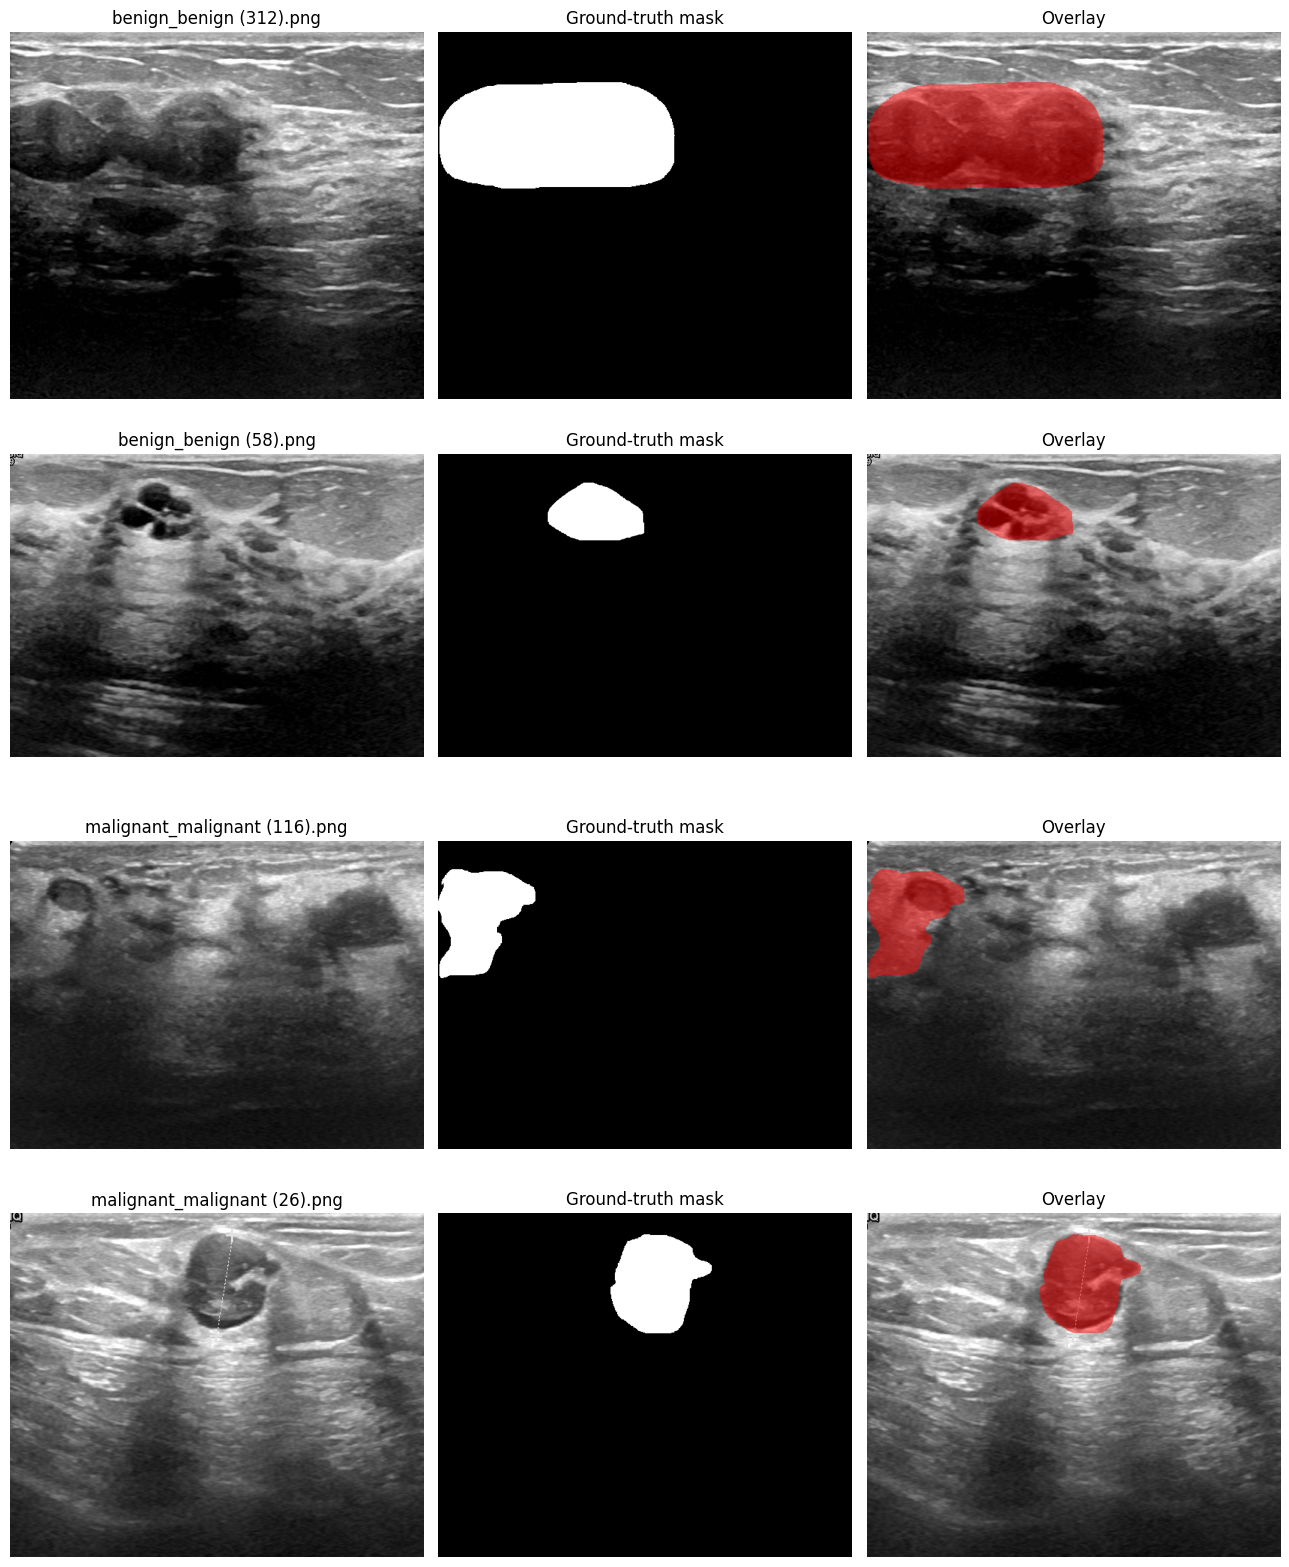

In [18]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

sample_names = random.sample(
    image_names,
    min(4, len(image_names))
)

fig, axes = plt.subplots(
    len(sample_names),
    3,
    figsize=(13, 4 * len(sample_names))
)

for row, name in enumerate(sample_names):
    image = cv2.imread(
        str(images_dir / name)
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    mask = cv2.imread(
        str(masks_dir / name),
        cv2.IMREAD_GRAYSCALE
    )

    overlay = image.copy()

    overlay[mask > 0] = (
        0.5 * overlay[mask > 0]
        + 0.5 * np.array([255, 0, 0])
    ).astype(np.uint8)

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(name)

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Ground-truth mask")

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title("Overlay")

    for column in range(3):
        axes[row, column].axis("off")

plt.tight_layout()
plt.show()

Cell 8 — Create the train/validation split

In [19]:
%cd /content/CMUNeXt

!rm -f data/busi/busi_train.txt
!rm -f data/busi/busi_val.txt

!python split.py \
    --dataset_name busi \
    --dataset_root ./data

/content/CMUNeXt
build train file successfully, path is: ./data/busi/busi_train.txt
build validate file successfully, path is: ./data/busi/busi_val.txt


Cell 9 — Verify the split

In [20]:
from pathlib import Path

train_file = Path(
    "/content/CMUNeXt/data/busi/busi_train.txt"
)

val_file = Path(
    "/content/CMUNeXt/data/busi/busi_val.txt"
)

train_ids = [
    line.strip()
    for line in train_file.read_text().splitlines()
    if line.strip()
]

val_ids = [
    line.strip()
    for line in val_file.read_text().splitlines()
    if line.strip()
]

overlap = set(train_ids) & set(val_ids)

print("Train:", len(train_ids))
print("Validation:", len(val_ids))
print("Total:", len(train_ids) + len(val_ids))
print("Overlap:", len(overlap))

assert train_ids, "Training split is empty."
assert val_ids, "Validation split is empty."
assert not overlap, "Train and validation sets overlap."

assert (
    len(train_ids) + len(val_ids)
    == len(image_names)
), "Split size does not match dataset size."

for case_id in train_ids + val_ids:
    assert (
        images_dir / f"{case_id}.png"
    ).exists(), f"Missing image: {case_id}"

    assert (
        masks_dir / f"{case_id}.png"
    ).exists(), f"Missing mask: {case_id}"

print("Split validation passed.")

Train: 452
Validation: 195
Total: 647
Overlap: 0
Split validation passed.


Cell 10 — Run one-epoch smoke test

In [21]:
%cd /content/CMUNeXt

!rm -rf checkpoint_smoke
!rm -f smoke_history.csv

!python -u train_colab.py \
    --model CMUNeXt-S \
    --base_dir ./data/busi \
    --train_file_dir busi_train.txt \
    --val_file_dir busi_val.txt \
    --base_lr 0.01 \
    --batch_size 8 \
    --image_size 256 \
    --max_epochs 1 \
    --num_workers 2 \
    --seed 41 \
    --checkpoint_dir ./checkpoint_smoke \
    --history_csv ./smoke_history.csv

/content/CMUNeXt
total 452  train samples
total 195  val samples
Training samples: 452, validation samples: 195
Model: CMUNeXt-S
Image size: 256
Batch size: 8
Epochs: 1
Initial learning rate: 0.01
Iterations per epoch: 57
Epoch [1/1] train_loss=1.1395, train_iou=0.1294, val_loss=1.0932, val_iou=0.0018, val_SE=0.0021, val_PC=0.0315, val_F1=0.0034, val_ACC=0.9038
=> Saved best checkpoint: checkpoint_smoke/CMUNeXt-S_busi_train_best.pth
=> Best validation IoU: 0.0018
Training finished.
Best validation IoU: 0.0018305741009093791
Best checkpoint: checkpoint_smoke/CMUNeXt-S_busi_train_best.pth


Cell 11 — Confirm smoke-test output

In [22]:
from pathlib import Path

checkpoints = list(
    Path(
        "/content/CMUNeXt/checkpoint_smoke"
    ).glob("*.pth")
)

print("Checkpoints:", checkpoints)

assert checkpoints, (
    "No checkpoint was saved."
)

print("Smoke test completed successfully.")

Checkpoints: [PosixPath('/content/CMUNeXt/checkpoint_smoke/CMUNeXt-S_busi_train_best.pth')]
Smoke test completed successfully.


In [23]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
from pathlib import Path
import shutil
import subprocess
import sys

import albumentations as A
import cv2
import numpy as np
import torch

results_dir = Path(
    "/content/drive/MyDrive/CMUNeXt_BASELINE_BUSI_SPLIT1"
)

checkpoint_dir = results_dir / "checkpoint"

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Results folder:", results_dir)

Results folder: /content/drive/MyDrive/CMUNeXt_BASELINE_BUSI_SPLIT1


In [25]:
from pathlib import Path
import shutil
import subprocess
import sys

train_file = Path(
    "/content/CMUNeXt/data/busi/busi_train.txt"
)

val_file = Path(
    "/content/CMUNeXt/data/busi/busi_val.txt"
)

shutil.copy2(
    train_file,
    results_dir / "busi_train.txt"
)

shutil.copy2(
    val_file,
    results_dir / "busi_val.txt"
)

shutil.copy2(
    "/content/CMUNeXt/train_colab.py",
    results_dir / "train_colab.py"
)

repository_commit = subprocess.check_output(
    [
        "git",
        "-C",
        "/content/CMUNeXt",
        "rev-parse",
        "HEAD"
    ],
    text=True
).strip()

environment_text = f"""
Repository commit: {repository_commit}
Python: {sys.version}
PyTorch: {torch.__version__}
CUDA version: {torch.version.cuda}
GPU: {torch.cuda.get_device_name(0)}
NumPy: {np.__version__}
OpenCV: {cv2.__version__}
Albumentations: {A.__version__}

Dataset: BUSI
Images: {len(image_names)}
Training samples: {len(train_ids)}
Validation samples: {len(val_ids)}

Model: CMUNeXt
Input size: 256x256
Batch size: 8
Optimizer: SGD
Initial learning rate: 0.01
Momentum: 0.9
Weight decay: 0.0001
Scheduler: Polynomial decay
Loss: BCE-Dice
Epochs: 300
Seed: 41
"""

(results_dir / "environment.txt").write_text(
    environment_text
)

print(environment_text)


Repository commit: affbf03ef631bb318d87b73ef97b2eacd0a5de85
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA version: 12.8
GPU: Tesla T4
NumPy: 2.0.2
OpenCV: 4.13.0
Albumentations: 2.0.8

Dataset: BUSI
Images: 647
Training samples: 452
Validation samples: 195

Model: CMUNeXt
Input size: 256x256
Batch size: 8
Optimizer: SGD
Initial learning rate: 0.01
Momentum: 0.9
Weight decay: 0.0001
Scheduler: Polynomial decay
Loss: BCE-Dice
Epochs: 300
Seed: 41



In [26]:
%cd /content/CMUNeXt

!set -o pipefail; python -u train_colab.py \
    --model CMUNeXt \
    --base_dir ./data/busi \
    --train_file_dir busi_train.txt \
    --val_file_dir busi_val.txt \
    --base_lr 0.01 \
    --batch_size 8 \
    --image_size 256 \
    --max_epochs 300 \
    --num_workers 2 \
    --seed 41 \
    --checkpoint_dir \
      /content/drive/MyDrive/CMUNeXt_BASELINE_BUSI_SPLIT1/checkpoint \
    --history_csv \
      /content/drive/MyDrive/CMUNeXt_BASELINE_BUSI_SPLIT1/training_history.csv \
    2>&1 | tee \
      /content/drive/MyDrive/CMUNeXt_BASELINE_BUSI_SPLIT1/training_log.txt

/content/CMUNeXt
total 452  train samples
total 195  val samples
Training samples: 452, validation samples: 195
Model: CMUNeXt
Image size: 256
Batch size: 8
Epochs: 300
Initial learning rate: 0.01
Iterations per epoch: 57
Epoch [1/300] train_loss=1.1233, train_iou=0.1762, val_loss=1.1009, val_iou=0.1763, val_SE=0.7581, val_PC=0.1977, val_F1=0.2690, val_ACC=0.6908
=> Saved best checkpoint: /content/drive/MyDrive/CMUNeXt_BASELINE_BUSI_SPLIT1/checkpoint/CMUNeXt_busi_train_best.pth
=> Best validation IoU: 0.1763
Epoch [2/300] train_loss=0.8837, train_iou=0.3106, val_loss=0.8343, val_iou=0.2934, val_SE=0.7055, val_PC=0.3841, val_F1=0.4119, val_ACC=0.8802
=> Saved best checkpoint: /content/drive/MyDrive/CMUNeXt_BASELINE_BUSI_SPLIT1/checkpoint/CMUNeXt_busi_train_best.pth
=> Best validation IoU: 0.2934
Epoch [3/300] train_loss=0.7580, train_iou=0.3639, val_loss=0.7089, val_iou=0.3810, val_SE=0.6459, val_PC=0.5170, val_F1=0.5042, val_ACC=0.9147
=> Saved best checkpoint: /content/drive/MyDrive/C

In [27]:
from pathlib import Path

results_dir = Path(
    "/content/drive/MyDrive/CMUNeXt_BASELINE_BUSI_SPLIT1"
)

for path in sorted(results_dir.rglob("*")):
    if path.is_file():
        print(
            path.relative_to(results_dir),
            "-",
            round(path.stat().st_size / 1024, 2),
            "KB"
        )

busi_train.txt - 9.56 KB
busi_val.txt - 4.1 KB
checkpoint/CMUNeXt_busi_train_best.pth - 12461.3 KB
environment.txt - 0.48 KB
train_colab.py - 9.62 KB
training_history.csv - 52.38 KB
training_log.txt - 46.93 KB


In [28]:
import pandas as pd

history_path = (
    "/content/drive/MyDrive/"
    "CMUNeXt_BASELINE_BUSI_SPLIT1/"
    "training_history.csv"
)

history = pd.read_csv(history_path)

best_index = history["validation_iou"].idxmax()
best_result = history.loc[best_index]

print("Best epoch:", int(best_result["epoch"]))
print(
    "Best validation IoU:",
    round(best_result["validation_iou"], 4)
)
print(
    "F1 at best epoch:",
    round(best_result["validation_f1"], 4)
)
print(
    "Sensitivity:",
    round(best_result["validation_sensitivity"], 4)
)
print(
    "Precision:",
    round(best_result["validation_precision"], 4)
)
print(
    "Accuracy:",
    round(best_result["validation_accuracy"], 4)
)
print(
    "Validation loss:",
    round(best_result["validation_loss"], 4)
)

display(history.tail())

Best epoch: 171
Best validation IoU: 0.6914
F1 at best epoch: 0.7736
Sensitivity: 0.7884
Precision: 0.8064
Accuracy: 0.9588
Validation loss: 0.3381


,epoch,learning_rate,train_loss,train_iou,validation_loss,validation_iou,validation_sensitivity,validation_precision,validation_f1,validation_accuracy
295,296,0.000206,0.080540,0.895382,0.372557,0.673813,0.765156,0.809880,0.759258,0.957195
296,297,0.000159,0.076848,0.902424,0.375499,0.672221,0.762738,0.804579,0.756874,0.957174
297,298,0.000111,0.078591,0.903077,0.372554,0.673338,0.760911,0.807555,0.758090,0.957347
298,299,0.000060,0.077458,0.901524,0.379664,0.670094,0.758161,0.806857,0.754009,0.956785
299,300,0.000002,0.076388,0.903263,0.372048,0.673861,0.766395,0.803137,0.759167,0.957061


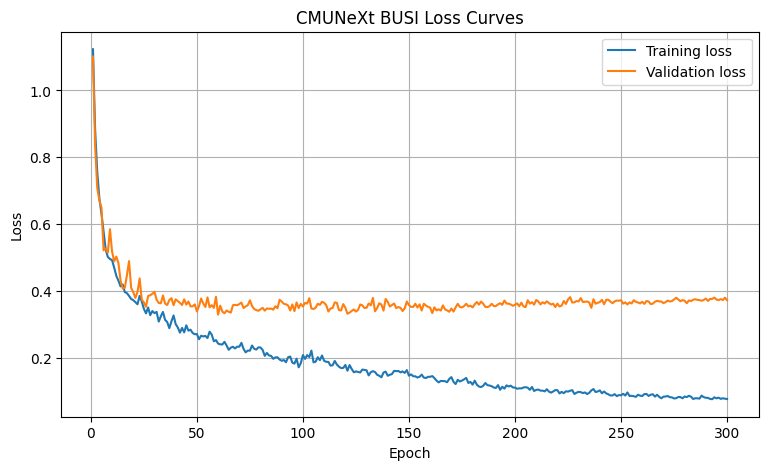

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

history = pd.read_csv(history_path)

plt.figure(figsize=(9, 5))

plt.plot(
    history["epoch"],
    history["train_loss"],
    label="Training loss"
)

plt.plot(
    history["epoch"],
    history["validation_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CMUNeXt BUSI Loss Curves")
plt.legend()
plt.grid()
plt.show()

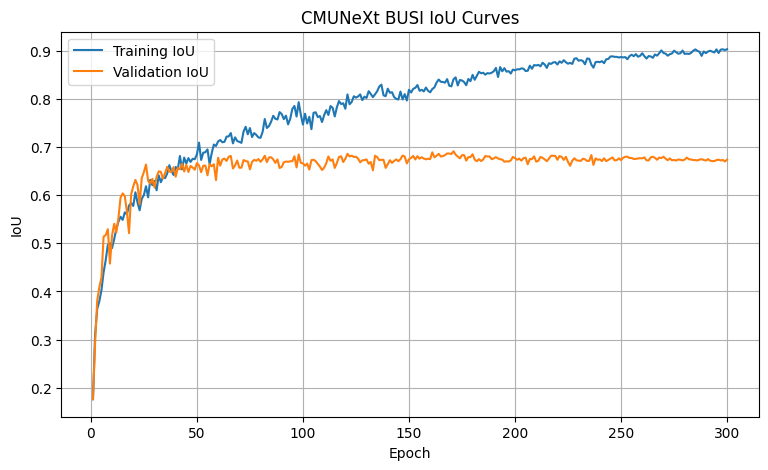

In [30]:
plt.figure(figsize=(9, 5))

plt.plot(
    history["epoch"],
    history["train_iou"],
    label="Training IoU"
)

plt.plot(
    history["epoch"],
    history["validation_iou"],
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("CMUNeXt BUSI IoU Curves")
plt.legend()
plt.grid()
plt.show()

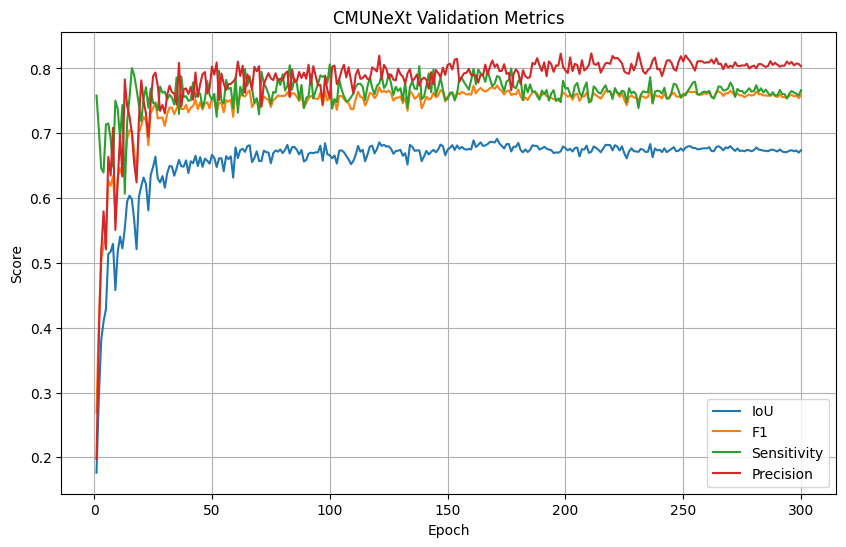

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    history["epoch"],
    history["validation_iou"],
    label="IoU"
)

plt.plot(
    history["epoch"],
    history["validation_f1"],
    label="F1"
)

plt.plot(
    history["epoch"],
    history["validation_sensitivity"],
    label="Sensitivity"
)

plt.plot(
    history["epoch"],
    history["validation_precision"],
    label="Precision"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("CMUNeXt Validation Metrics")
plt.legend()
plt.grid()
plt.show()

In [32]:
import torch
from network.CMUNeXt import cmunext

checkpoint_path = (
    "/content/drive/MyDrive/"
    "CMUNeXt_BASELINE_BUSI_SPLIT1/"
    "checkpoint/"
    "CMUNeXt_busi_train_best.pth"
)

model = cmunext().cuda()

state_dict = torch.load(
    checkpoint_path,
    map_location="cuda"
)

model.load_state_dict(state_dict)
model.eval()

print("Best CMUNeXt checkpoint loaded.")

Best CMUNeXt checkpoint loaded.


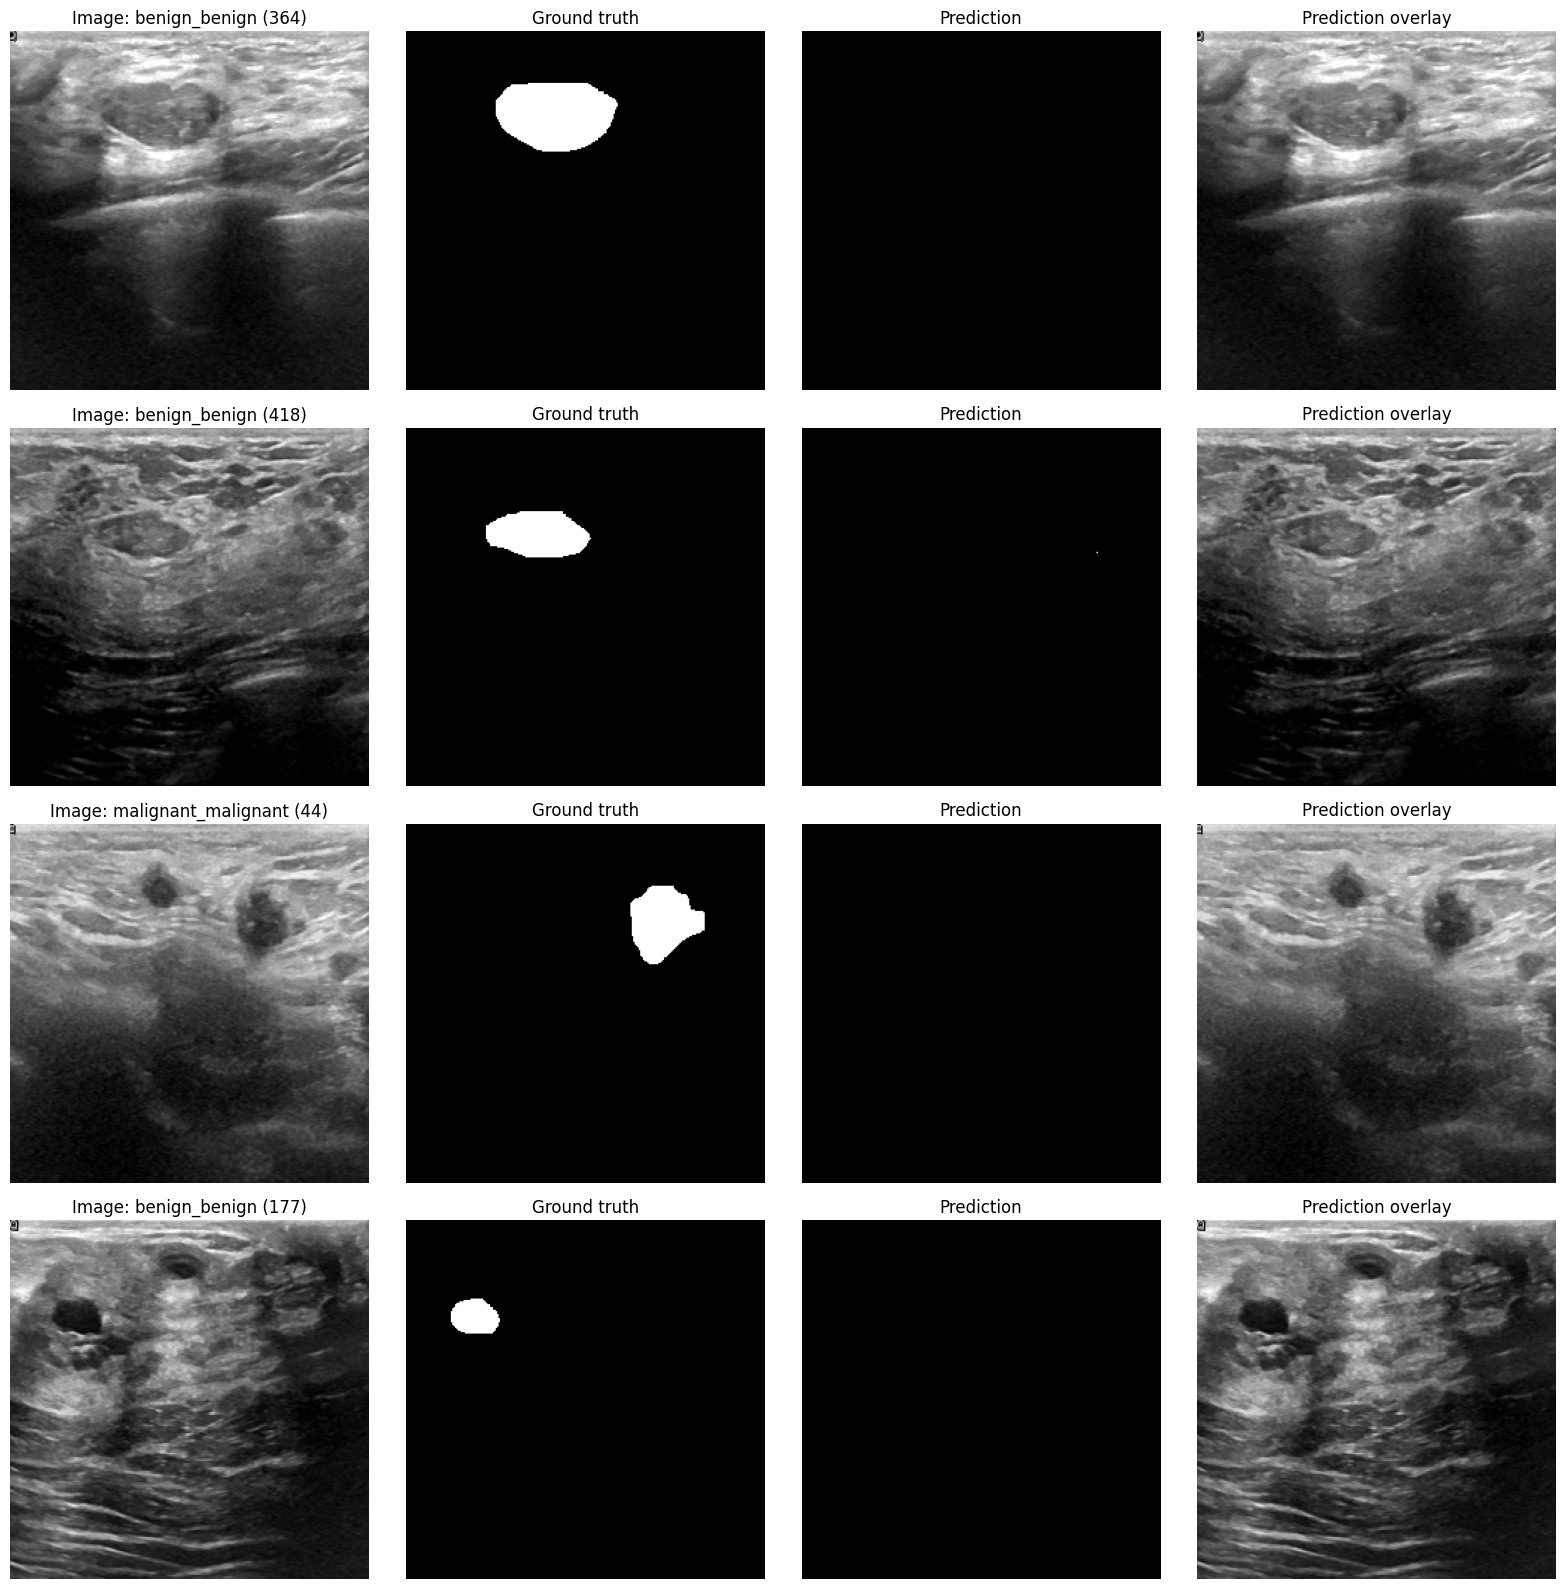

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import albumentations as A

validation_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
])

sample_ids = random.sample(
    val_ids,
    min(4, len(val_ids))
)

fig, axes = plt.subplots(
    len(sample_ids),
    4,
    figsize=(16, 4 * len(sample_ids))
)

for row, case_id in enumerate(sample_ids):
    image_path = images_dir / f"{case_id}.png"
    mask_path = masks_dir / f"{case_id}.png"

    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    ground_truth = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    transformed = validation_transform(
        image=image_rgb
    )

    input_tensor = torch.from_numpy(
        transformed["image"]
    ).permute(2, 0, 1).float().unsqueeze(0).cuda()

    with torch.no_grad():
        logits = model(input_tensor)
        probability = torch.sigmoid(logits)
        prediction = (
            probability > 0.5
        ).float()

    prediction = (
        prediction.squeeze()
        .cpu()
        .numpy()
        .astype(np.uint8)
        * 255
    )

    resized_gt = cv2.resize(
        ground_truth,
        (256, 256),
        interpolation=cv2.INTER_NEAREST
    )

    resized_image = cv2.resize(
        image_rgb,
        (256, 256)
    )

    overlay = resized_image.copy()
    overlay[prediction > 0] = (
        0.5 * overlay[prediction > 0]
        + 0.5 * np.array([255, 0, 0])
    ).astype(np.uint8)

    axes[row, 0].imshow(resized_image)
    axes[row, 0].set_title(f"Image: {case_id}")

    axes[row, 1].imshow(
        resized_gt,
        cmap="gray"
    )
    axes[row, 1].set_title("Ground truth")

    axes[row, 2].imshow(
        prediction,
        cmap="gray"
    )
    axes[row, 2].set_title("Prediction")

    axes[row, 3].imshow(overlay)
    axes[row, 3].set_title("Prediction overlay")

    for column in range(4):
        axes[row, column].axis("off")

plt.tight_layout()
plt.show()